Exploration of the scenarios for the post-event GM prediction method.   
Only applicable for observed data, does not support simulations.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from IPython.display import display, Markdown

import sim_ranking as sr
import ml_tools as mlt
import spatial_hazard as sh

# sns.set_theme(style="white")

In [2]:
# Disable FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Config
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.0/Tables/ground_motion_im_table_rotd50_flat.csv")
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.3/Tables/ground_motion_im_table_rotd50_flat.csv")
# nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v3.4/Tables/ground_motion_im_table_rotd50_flat.csv")
nzgmdb_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v4.2/custom/mod_ground_motion_im_table_rotd50_flat.csv")


**NZGMDB File Path:** `{python} str(nzgmdb_ffp)`  
**NZGMDB version:** `{python} str(nzgmdb_ffp.parent.parent.name)` 

In [4]:
min_pga = 0.0025

max_dist=30
closest_max_dist=10
max_n_obs_sites=20
min_n_obs_sites=2

In [5]:
# Injected Parameters
min_pga = 0.0025
max_dist = 30
closest_max_dist = 10
max_n_obs_sites = 10
min_n_obs_sites = 2


**Minimum PGA:** `{python} str(min_pga)`  
**Maximum Distance:** `{python} str(max_dist)`  
**Closest Maximum Distance:** `{python} str(closest_max_dist)`  
**Maximum Number of Observation Sites:** `{python} str(max_n_obs_sites)`  
**Minimum Number of Observation Sites:** `{python} str(min_n_obs_sites)`

In [6]:
### Data loading
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)

events, all_sites = obs_data.events, obs_data.sites
event_sites = obs_data.event_sites
print(f"Number of events: {len(events)}")
print(f"Number of sites: {len(all_sites)}")
print(f"Number of records: {obs_data.n_records}")

Number of events: 3809
Number of sites: 383
Number of records: 72457


## Valid SOI selection
### Selection of SOI using observed PGA

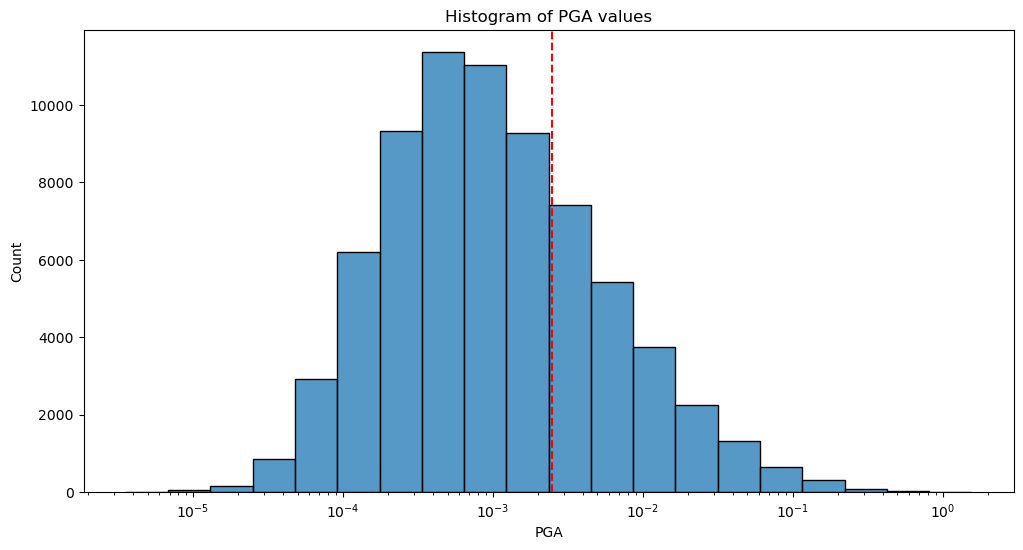

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(obs_data.record_df.PGA, bins=20, ax=ax, log_scale=(True, False))
ax.axvline(min_pga, color='r', linestyle='--')
ax.set_title("Histogram of PGA values");

In [8]:
cur_record_df = obs_data.record_df[obs_data.record_df.PGA > min_pga]

Select the records with PGA values greater than a threshold value of `{python} str(min_pga)`.  
Number of records selected: `{python} str(len(cur_record_df))`. 

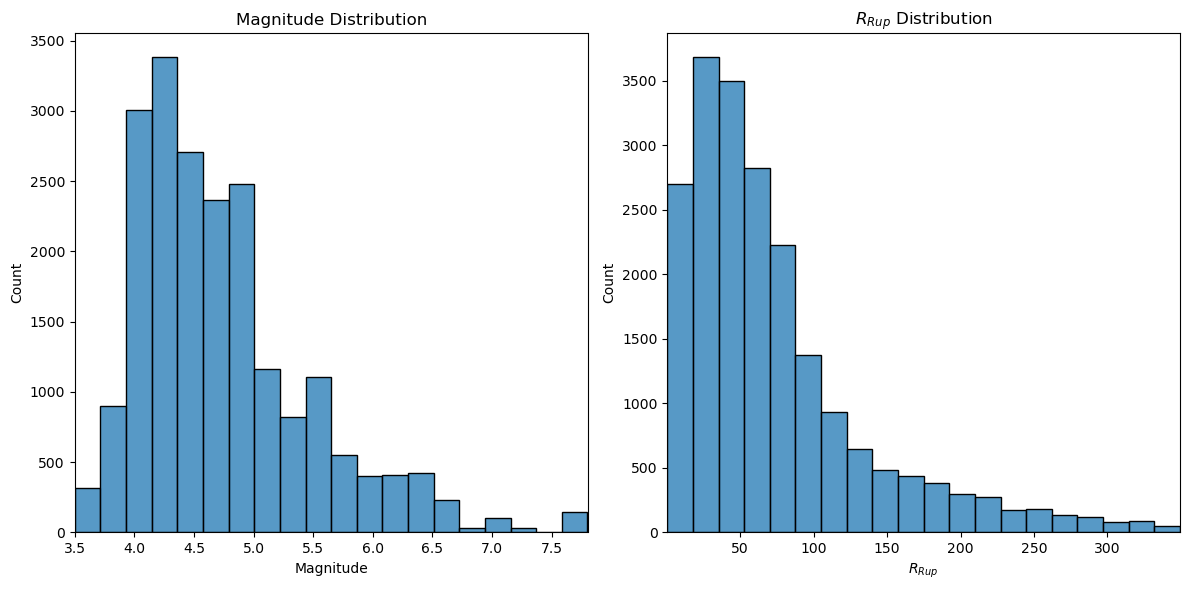

In [9]:
# Plot magnitude & distance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(cur_record_df["mag"], bins=20, ax=ax1)
ax1.set_title("Magnitude Distribution")
ax1.set_xlabel("Magnitude")
ax1.set_xlim(cur_record_df["mag"].min(), cur_record_df["mag"].max())

sns.histplot(cur_record_df["rrup"], bins=20, ax=ax2)
ax2.set_title("$R_{Rup}$ Distribution")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_xlim(cur_record_df["rrup"].min(), cur_record_df["rrup"].max())

fig.tight_layout()


### Valid site calculation using GMM
Only consider records that would experience shaking PGA > `{python} str(min_pga)`, based on the Bradley 2013 GMPE.

In [10]:
# Get the set of valid site-interests per event
print("Getting valid sites of interest")
valid_int_sites, valid_event_int_sites, valid_record_ids = sr.ml.data.get_valid_site_ints(
    obs_data.event_sites, obs_data.record_df.drop(columns=obs_data.ims), min_pga=min_pga
)
cur_record_df = obs_data.record_df.loc[valid_record_ids]

Getting valid sites of interest
Valid SOI records: 28618/72457


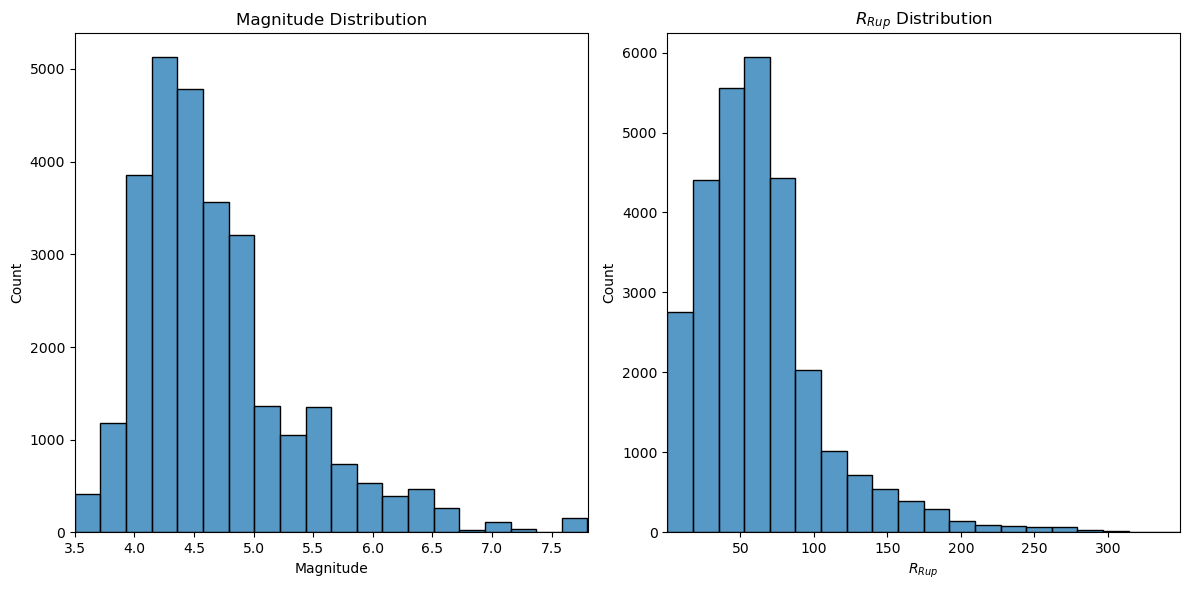

In [11]:
# Plot magnitude & distance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(cur_record_df["mag"], bins=20, ax=ax1)
ax1.set_title("Magnitude Distribution")
ax1.set_xlabel("Magnitude")
ax1.set_xlim(cur_record_df["mag"].min(), cur_record_df["mag"].max())

sns.histplot(cur_record_df["rrup"], bins=20, ax=ax2)
ax2.set_title("$R_{Rup}$ Distribution")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_xlim(cur_record_df["rrup"].min(), cur_record_df["rrup"].max())

fig.tight_layout()


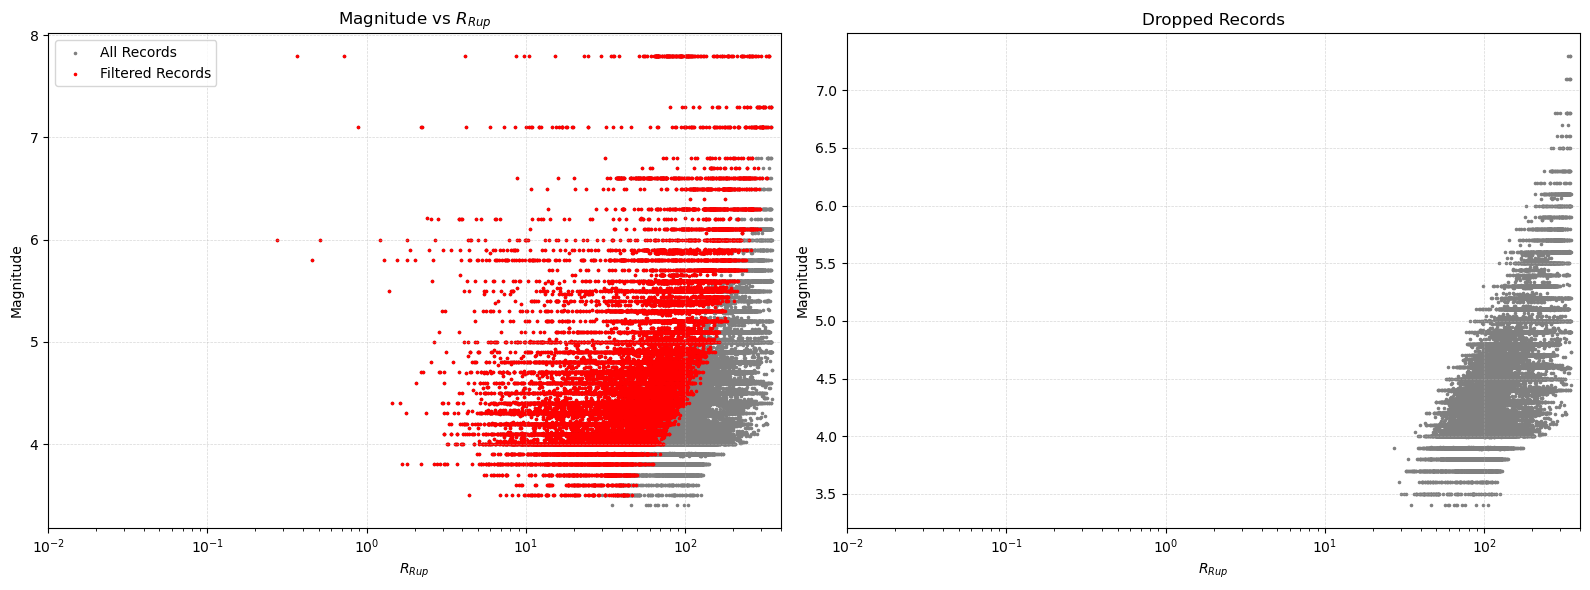

In [12]:
# Magnitude vs $R_{Rup}$ scatter plot
fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, ind_figsize=(8, 6))

ax1.scatter(obs_data.record_df["rrup"], obs_data.record_df["mag"], c="grey", s=2.5, label="All Records")
ax1.scatter(cur_record_df["rrup"], cur_record_df["mag"], c="red", s=2.5, label="Filtered Records")

ax1.set_title("Magnitude vs $R_{Rup}$")
ax1.set_xlabel("$R_{Rup}$")
ax1.set_ylabel("Magnitude")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xscale("log")
ax1.set_xlim(0.01, 400)
ax1.xaxis.set_minor_locator(ticker.LogLocator(base=10, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))
ax1.legend()

# Dropped Records
dropped_records = obs_data.record_df[~obs_data.record_df.index.isin(cur_record_df.index)].index.values.astype(str)
ax2.scatter(obs_data.record_df.loc[dropped_records, "rrup"], obs_data.record_df.loc[dropped_records, "mag"], c="grey", s=2.5)
ax2.set_title("Dropped Records")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_ylabel("Magnitude")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xscale("log")
ax2.set_xlim(0.01, 400)



fig.tight_layout()

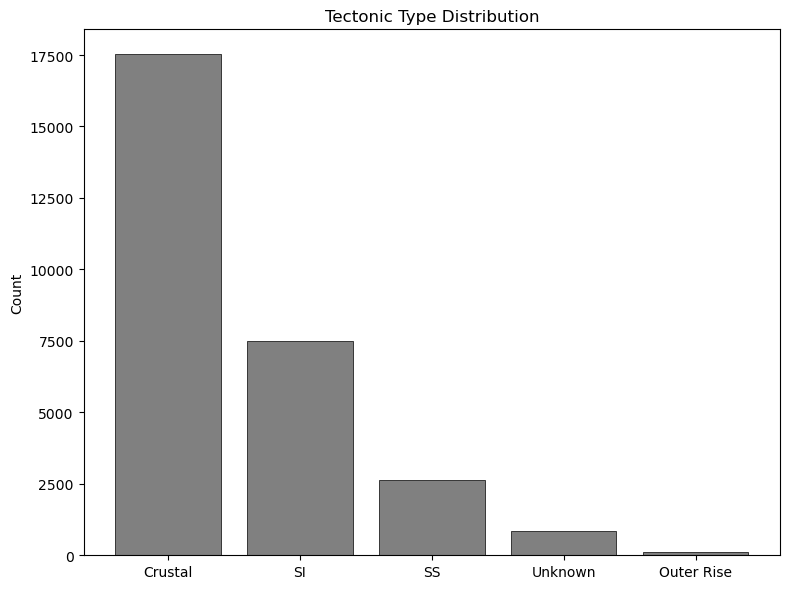

In [13]:
tect_type_count = cur_record_df.tect_type.value_counts()
tect_type_count = tect_type_count.rename(index={"crustal": "Crustal", "subduction_interface": "SI", "subduction_slab": "SS", "unknown": "Unknown", "outer_rise": "Outer Rise"})

fig, ax = plt.subplots(figsize=(8, 6))

plt.bar(
    tect_type_count.index,
    tect_type_count.values,
    color="grey",
    edgecolor="black",
    linewidth=0.5,
    align="center",
)
ax.set_title("Tectonic Type Distribution")
# ax.set_xlabel("Tectonic Type")
ax.set_ylabel("Count")
# ax.xaxis.set_tick_params(rotation=90)

fig.tight_layout()

## Scenarios

In [14]:
# def run_scenario_computation(max_dist: int, closest_max_dist: int, max_n_obs_sites: int, min_n_obs_sites: int):
#     # Compute potential scenarios
#     dist_matrix = sr.utils.calculate_distance_matrix(all_sites, obs_data.site_df)
#     lb_corr_data = sr.LBSiteCorrelationData.from_dist_matrix(dist_matrix, sr.constants.PSA_KEYS)
    
#     valid_events = list(valid_event_int_sites.keys())
#     event_site_combs, used_event_sites = sr.ml.data.compute_site_combinations(
#             event_sites,
#             valid_event_int_sites,
#             valid_events,
#             dist_matrix,
#             obs_data.sites,
#             obs_data.sites,
#             max_dist=max_dist,
#             closest_max_dist=closest_max_dist,
#             max_n_obs_sites=max_n_obs_sites,
#             min_n_obs_sites=min_n_obs_sites,
#         )
    
#     # Get scenario df
#     scenario_df = sr.ml.utils.create_scenario_df(event_site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=lb_corr_data)
    
#     print(f"Number of events: {scenario_df.event.nunique()}")
#     print(f"Number of scenarios: {scenario_df.shape[0]}")
    
#     # Plot number of observations sites & degree of constraint distribution
#     fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
#     sns.histplot(scenario_df.n_obs_sites, bins=20, ax=ax1)
#     ax1.set_title("Number of observation sites")
#     ax1.set_xlabel("Number of observation sites")
#     ax1.set_xlim(0, scenario_df.n_obs_sites.max())
    
#     sns.histplot(scenario_df.constraintness, bins=20, ax=ax2)
#     ax2.set_title("Degree of constraint")
#     ax2.set_xlabel("Degree of constraint")
#     ax2.set_xlim(0, scenario_df.constraintness.max())
    
#     fig.tight_layout()
    
#     # Number of observations vs rrup
#     g = sns.jointplot(data=scenario_df, x="rrup", y="constraintness", kind="hex", marginal_kws=dict(bins=20), height=8, joint_kws=dict(gridsize=40), )
    
#     # Number of observations vs mag
#     g = sns.jointplot(data=scenario_df, x="mag", y="constraintness", kind="hex", marginal_kws=dict(bins=20), height=8, joint_kws=dict(gridsize=40), )

In [15]:
# Compute potential scenarios
dist_matrix = sh.im_dist.calculate_distance_matrix(all_sites, obs_data.site_df)
lb_corr_data = sr.LBSiteCorrelationData.from_dist_matrix(dist_matrix, sr.constants.PSA_KEYS)

valid_events = list(valid_event_int_sites.keys())
event_site_combs, used_event_sites = sr.ml.data.compute_site_combinations(
        event_sites,
        valid_event_int_sites,
        valid_events,
        dist_matrix,
        obs_data.sites,
        obs_data.sites,
        max_dist=max_dist,
        closest_max_dist=closest_max_dist,
        max_n_obs_sites=max_n_obs_sites,
        min_n_obs_sites=min_n_obs_sites,
    )

# Get scenario df
scenario_df = sr.ml.utils.create_scenario_df(event_site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=lb_corr_data)

print(f"Number of events: {scenario_df.event.nunique()}")
print(f"Number of scenarios: {scenario_df.shape[0]}")

Number of events: 1207
Number of scenarios: 17100


### Degree of Constraint

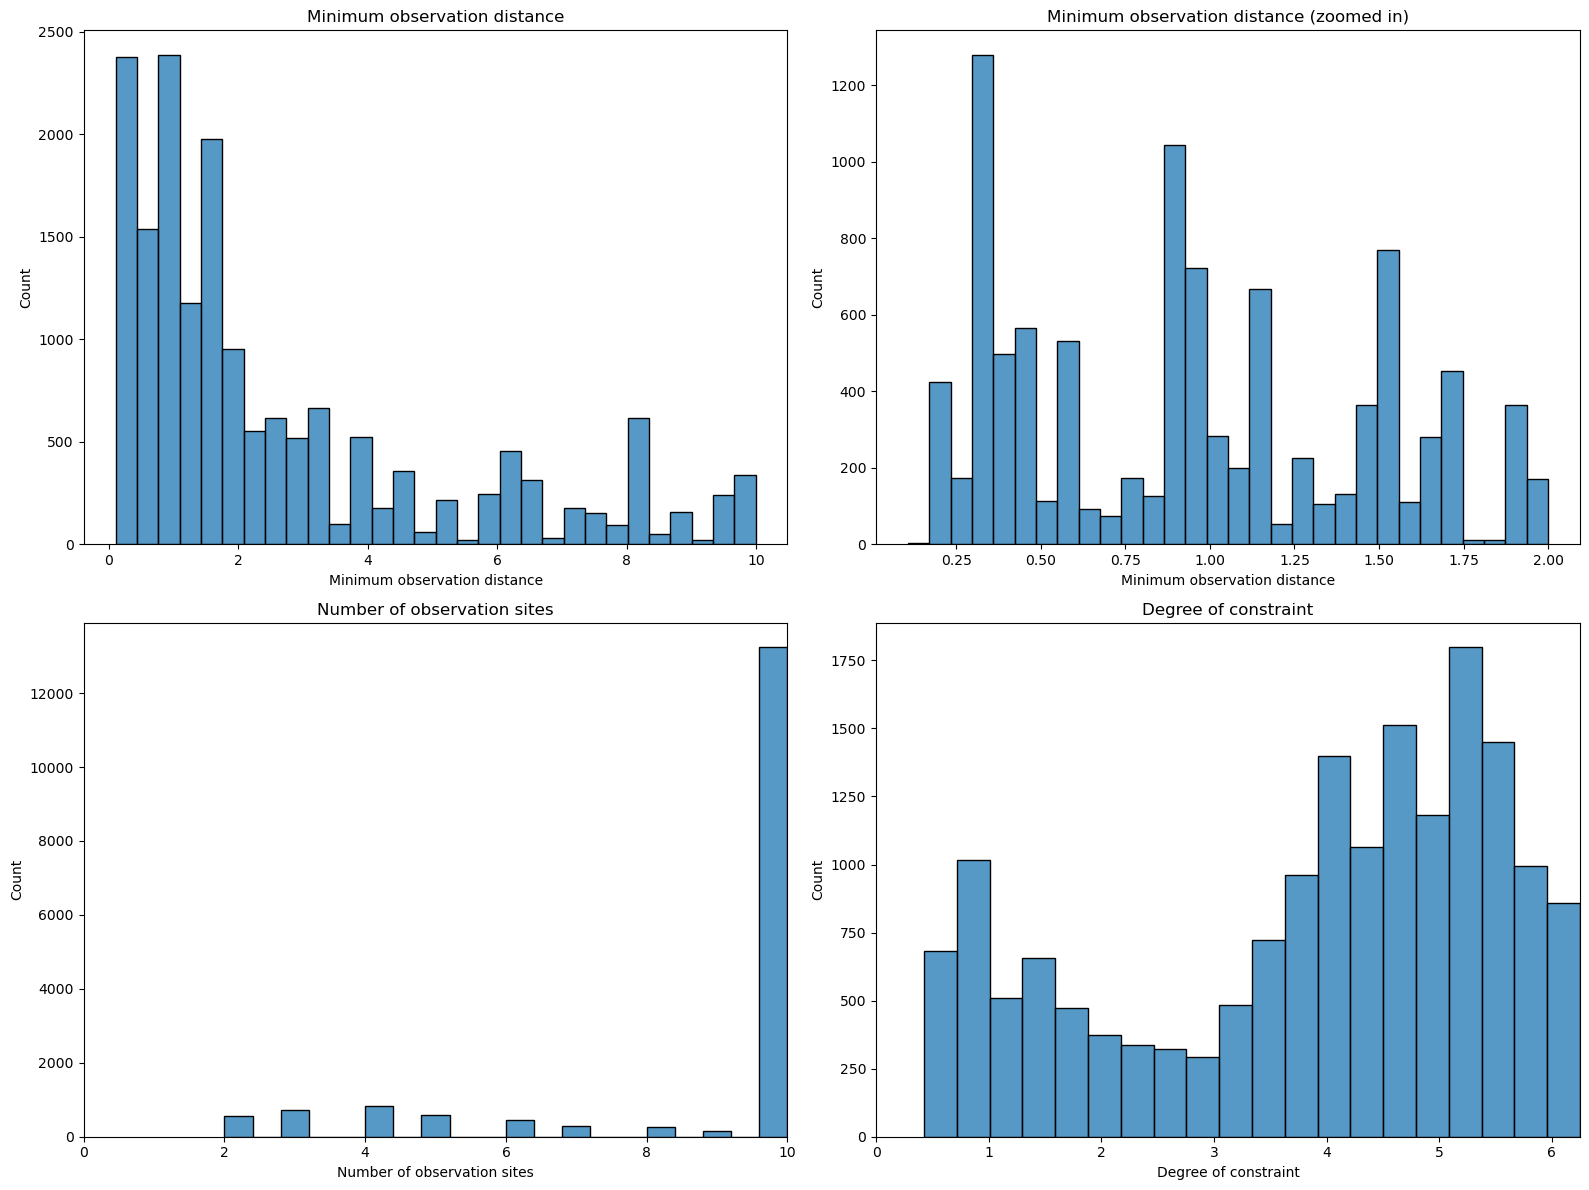

In [16]:
fig, (ax1, ax2, ax3, ax4) = mlt.plotting.get_fig_axes(4, 2, 2, ind_figsize=(8, 6))

# Minimum observation distance
sns.histplot(scenario_df.min_obs_distance, bins=30, ax=ax1)
ax1.set_title("Minimum observation distance")
ax1.set_xlabel("Minimum observation distance")

# Minium observation distance (zoomed in)
sns.histplot(scenario_df.loc[scenario_df.min_obs_distance < 2].min_obs_distance, bins=30, ax=ax2)
ax2.set_title("Minimum observation distance (zoomed in)")
ax2.set_xlabel("Minimum observation distance")

# Number of observations sites 
sns.histplot(scenario_df.n_obs_sites, bins=20, ax=ax3)
ax3.set_title("Number of observation sites")
ax3.set_xlabel("Number of observation sites")
ax3.set_xlim(0, scenario_df.n_obs_sites.max())

# Degree of constraint distribution
sns.histplot(scenario_df.constraintness, bins=20, ax=ax4)
ax4.set_title("Degree of constraint")
ax4.set_xlabel("Degree of constraint")
ax4.set_xlim(0, scenario_df.constraintness.max())

fig.tight_layout()

### Magnitude - Distance Scatter Plot

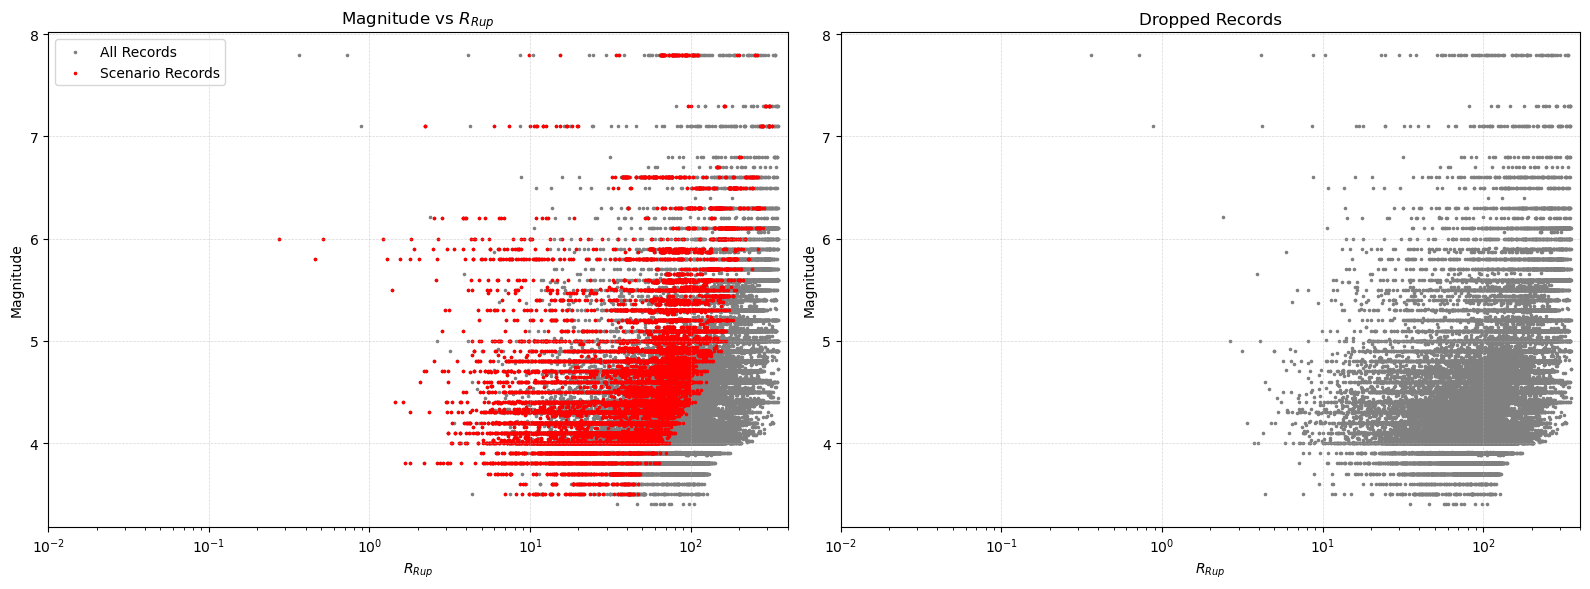

In [17]:
# Magnitude vs $R_{Rup}$ scatter plot
fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, ind_figsize=(8, 6))

ax1.scatter(obs_data.record_df["rrup"], obs_data.record_df["mag"], c="grey", s=2.5, label="All Records")
ax1.scatter(scenario_df["rrup"], scenario_df["mag"], c="red", s=2.5, label="Scenario Records")

ax1.set_title("Magnitude vs $R_{Rup}$")
ax1.set_xlabel("$R_{Rup}$")
ax1.set_ylabel("Magnitude")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xscale("log")
ax1.set_xlim(0.01, 400)
ax1.legend()

# Dropped Records
dropped_records = obs_data.record_df[~obs_data.record_df.index.isin(scenario_df.index)].index.values.astype(str)
ax2.scatter(obs_data.record_df.loc[dropped_records, "rrup"], obs_data.record_df.loc[dropped_records, "mag"], c="grey", s=2.5)
ax2.set_title("Dropped Records")
ax2.set_xlabel("$R_{Rup}$")
ax2.set_ylabel("Magnitude")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xscale("log")
ax2.set_xlim(0.01, 400)


fig.tight_layout()

fig.tight_layout()

### Tectonic Type Distribution

| tect_type   |   count |
|:------------|--------:|
| Crustal     |   10618 |
| SI          |    4776 |
| SS          |    1213 |
| Unknown     |     455 |
| Outer Rise  |      38 |

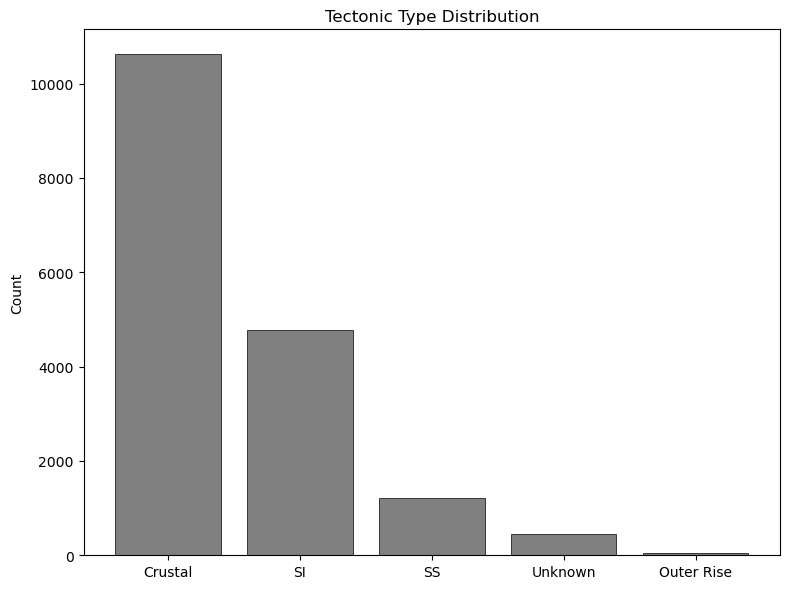

In [18]:

tect_type_count = obs_data.record_df.loc[scenario_df.index.values].tect_type.value_counts()
tect_type_count = tect_type_count.rename(index={"crustal": "Crustal", "subduction_interface": "SI", "subduction_slab": "SS", "unknown": "Unknown", "outer_rise": "Outer Rise"})

display(Markdown(tect_type_count.to_markdown()))

fig, ax = plt.subplots(figsize=(8, 6))

plt.bar(
    tect_type_count.index,
    tect_type_count.values,
    color="grey",
    edgecolor="black",
    linewidth=0.5,
    align="center",
)
ax.set_title("Tectonic Type Distribution")
# ax.set_xlabel("Tectonic Type")
ax.set_ylabel("Count")
# ax.xaxis.set_tick_params(rotation=90)

fig.tight_layout()

### Effect of $F_{min}$ Filtering 

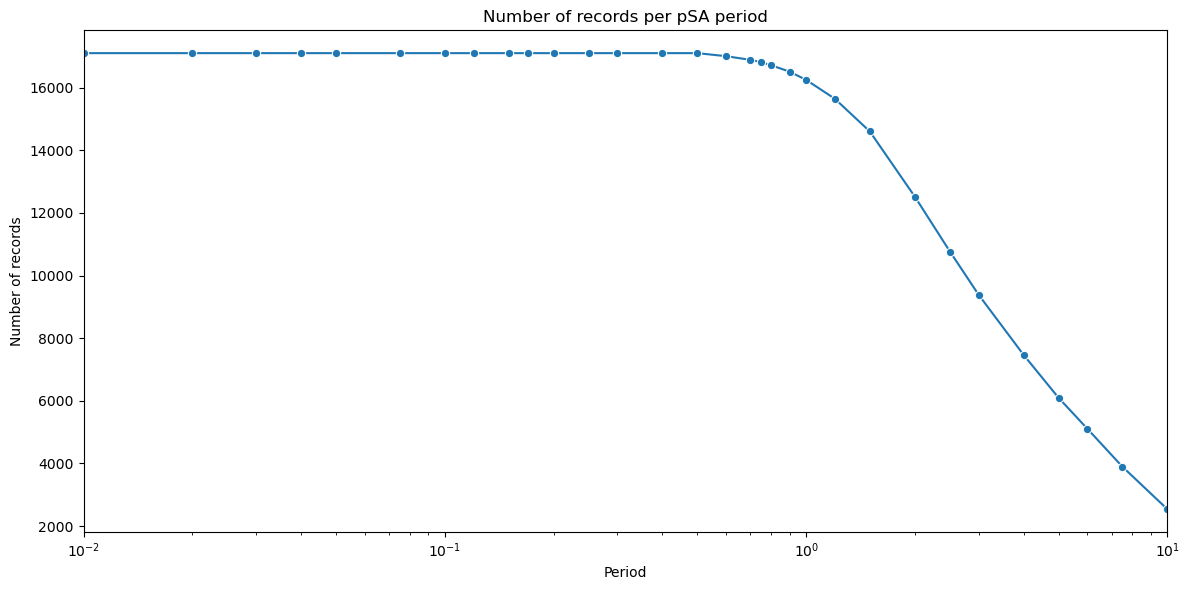

In [19]:
# Compute the number of scenarios per pSA period
n_im_records = pd.Series({float(cur_pSA.split("_")[1]): np.sum(~np.isnan(obs_data.record_df.loc[scenario_df.index, cur_pSA]))  for cur_pSA in sr.constants.PSA_KEYS})

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x=sr.constants.PERIODS, y=n_im_records.values, ax=ax, marker="o")

ax.set_title("Number of records per pSA period")
ax.set_xlabel("Period")
ax.set_ylabel("Number of records")
ax.set_xscale("log")
ax.set_xlim(0.01, 10)

fig.tight_layout()
